In [1]:
# ---- Core scientific stack ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# ---- Image analysis ----
from skimage.metrics import structural_similarity as ssim

# ---- Dimensionality reduction & clustering ----
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap

%matplotlib inline
%run classifiers_functions.ipynb

C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data visialization Part 1

## First we load the preprocessed data into the workspace. We will start with a mouse brain dataset, although if you are feeling adventurous you can also load in your own MSI data

## the format should be standardised, the first 2 columns denote the pixel coordinates and column 3 onwards are the vectorised pixel intensities for each detected ion features, which is labelled by the 1st row e.g., column 5 includes the intensity of the feature m/z 93.034 for all pixels.

In [2]:
# Data load in
# change filepath
file = r"h5_csv_mice_brain.csv"
tmp_train, data, mz = load_data(file,features = None)
tmp_train

data already has the same spectral variables


,X,Y,88.038,93.03,93.032,93.034,93.036,99.006,99.008,101.06,...,1129.739,1130.741,1131.742,1132.747,1166.776,1167.77,1168.781,1182.769,1189.685,1194.806
0,1,1,0,99,99,105,105,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2,0,163,163,163,0,62,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,3,0,0,139,139,139,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,4,0,143,143,143,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17152,133,125,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17153,133,126,0,0,0,96,96,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17154,133,127,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17155,133,128,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## The first, easiest way to visualise the whole dataset is called a **total-ion-count (TIC) image**.

## Just like the normalisation approach of the same name, we **sum** all intensities across all m/z features at every pixel and form basically a sum intensity image, this effectively includes all the ion contributions at every spatial location and should give some rough idea of the morphology.

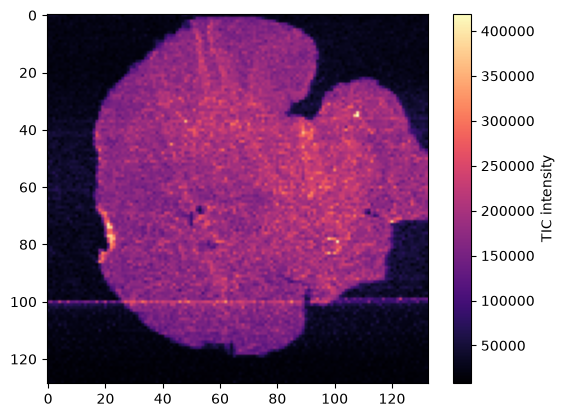

In [3]:
tic = data.sum(axis=1)

x = tmp_train['X']
y = tmp_train['Y']
img = np.full((y.max(), x.max()), np.nan)
img[y - 1, x - 1] = tic

plt.imshow(img, cmap="magma", origin="upper")
plt.axis("image")
plt.colorbar(label="TIC intensity")
plt.show()

## we can also inspect the **TIC spectrum**, which requires us to sum across all rows - so the same concept but now we include all intensities from every pixel for each m/z feature.

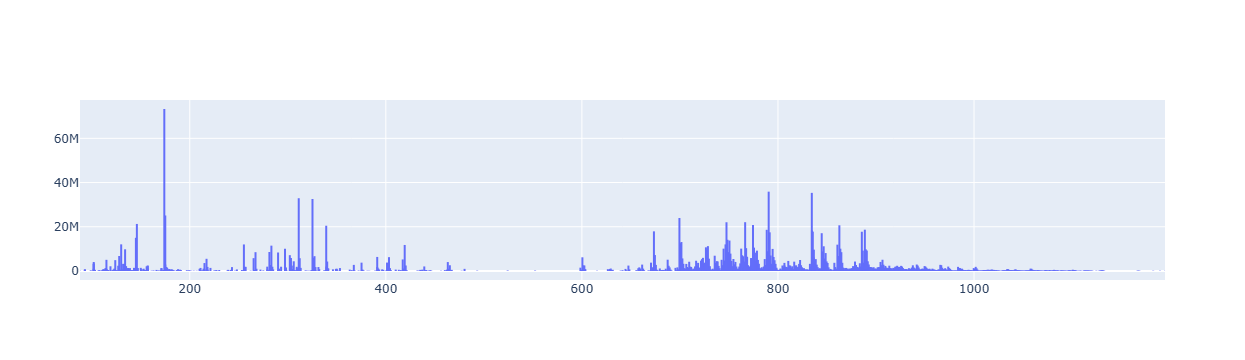

In [32]:
tic_spectrum = (data.sum(axis=0))

fig = go.Figure(go.Scatter(
    x=np.repeat(mz, 3),
    y=np.ravel(np.column_stack([np.zeros_like(tic_spectrum), tic_spectrum, np.nan * tic_spectrum])),
    mode="lines"
))

fig.show()

## You can zoom & pan the spectrum freely, note how many features there are just in one dataset!

## We can also visualise these features individually with an **ion image** - so we find a peak and get all its pixel intensities to form an image.
## Try this with the function below, pick some peaks-of-interest and try to visualise them.

## the syntax is `plot_xic(feature)`, where feature = e.g., 174.04, 2 decimal places should be accurate enough.

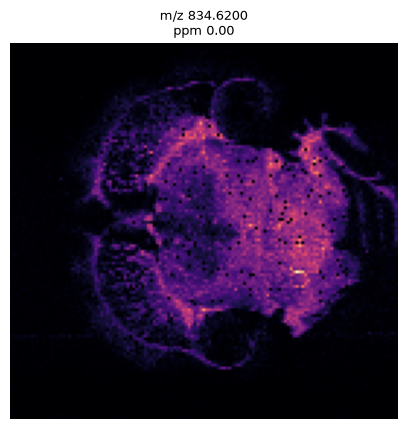

In [14]:
ref_img=plot_xic(834.62, max_x = x.max(), max_y = y.max())

## Now we've had some idea of what's in the dataset, let's be hollistic and look at the top 10 features.

## How dow we rank features? First, let's try by intensity:

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_31840\22415110.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{current_title}\nTIC {tic_spectrum[i]:.3g}",


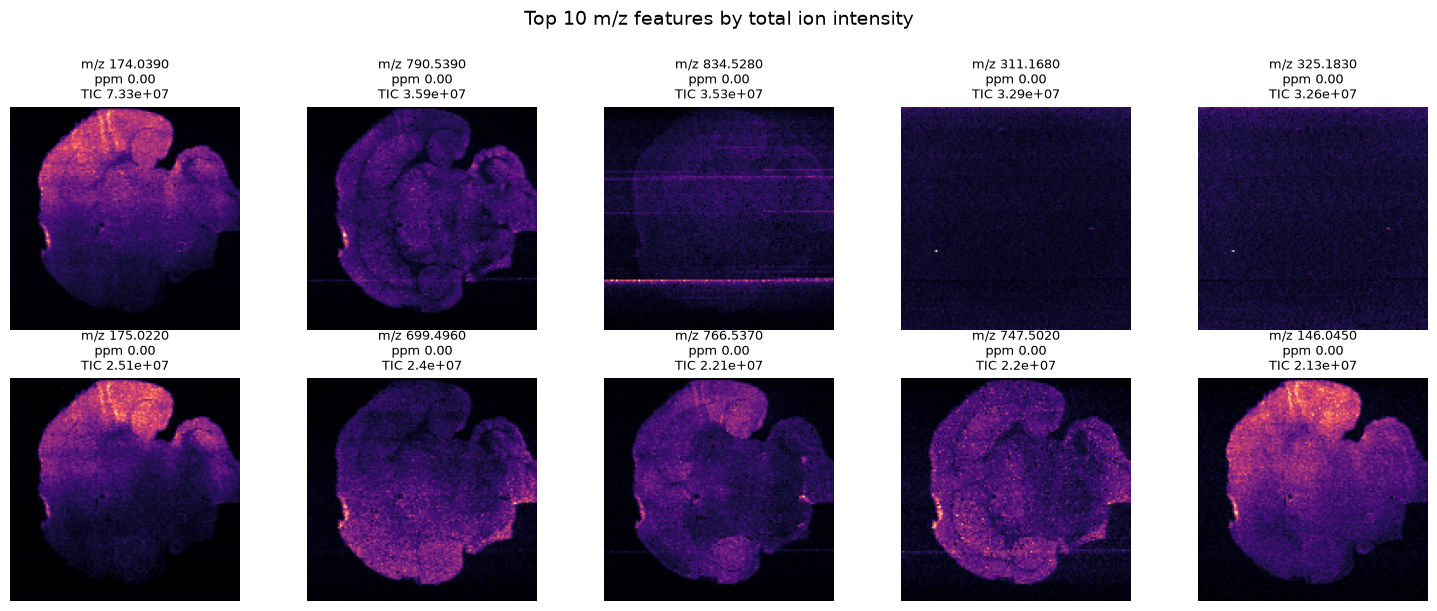

In [15]:
# Ten highest-TIC feature columns, ordered highest to lowest.
top10_idx = np.argsort(tic_spectrum)[-10:][::-1]

fig, ax = plt.subplots(2, 5, figsize=(15, 6))
ax = ax.ravel()

for a, i in zip(ax, top10_idx):
    plot_xic(
        data = data,
        target_mz=mz[i],
        max_x = x.max(), 
        max_y = y.max(),
        ax=a,
        add_colorbar=False
    )

    # Add the summed intensity under the m/z/ppm title.
    current_title = a.get_title()

    a.set_title(
        f"{current_title}\nTIC {tic_spectrum[i]:.3g}",
        fontsize=9
    )

fig.suptitle(
    "Top 10 m/z features by total ion intensity",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

## Do they look like *good* features? Let's try another way to rank the top 10 features, we will use what is called **Shannon's entropy**, which is effectively a binary way of measuring informaiton in the image.

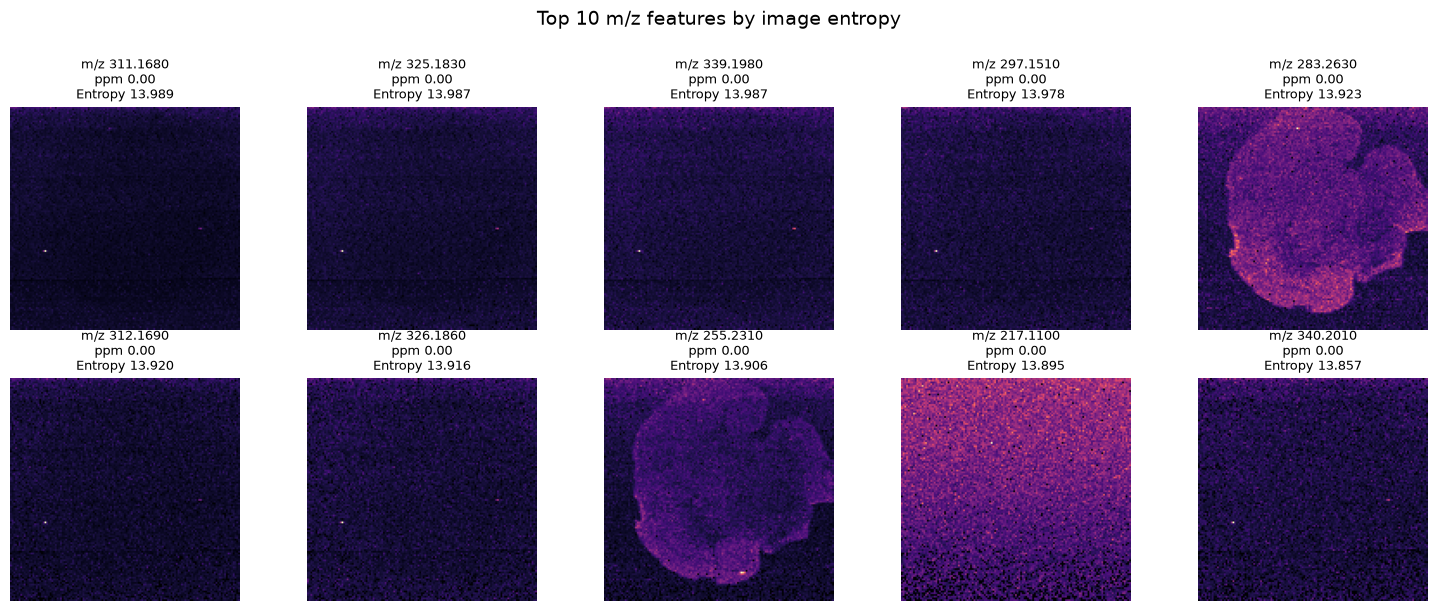

In [16]:
# Convert data once: works for either pandas DataFrame or NumPy array.
X = (
    data.to_numpy(dtype=float)
    if hasattr(data, "to_numpy")
    else np.asarray(data, dtype=float)
)

# Replace NaN/Inf and exclude negative values before calculating probabilities.
X = np.nan_to_num(
    X,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)
X = np.clip(X, 0, None)

# Normalize every m/z feature column independently:
# P[pixel, feature] = intensity / total intensity for that feature.
feature_sum = X.sum(axis=0)
safe_sum = np.where(feature_sum > 0, feature_sum, 1.0)
P = X / safe_sum

# Shannon entropy per feature image, with 0 * log2(0) treated as 0.
logP = np.zeros_like(P)
nonzero = P > 0
logP[nonzero] = np.log2(P[nonzero])

entropy_spectrum = -(P * logP).sum(axis=0)

# Empty ion images should not rank among the top features.
entropy_spectrum[feature_sum == 0] = 0.0

# Feature indices with the ten highest image entropies.
top10_idx = np.argsort(entropy_spectrum)[-10:][::-1]

fig, ax = plt.subplots(2, 5, figsize=(15, 6))
ax = ax.ravel()

for a, i in zip(ax, top10_idx):
    plot_xic(
        target_mz=mz[i],
        max_x = x.max(), 
        max_y = y.max(),
        ax=a,
        add_colorbar=False
    )

    # Preserve the m/z and ppm title generated by plot_xic.
    a.set_title(
        f"{a.get_title()}\nEntropy {entropy_spectrum[i]:.3f}",
        fontsize=9
    )

fig.suptitle(
    "Top 10 m/z features by image entropy",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

## So what's wrong? two important subtleties;
## 1. High intensity peaks do not necessarily carry more spatial information - a background peak that is uniformly spread across the whole image is just as likely (if not more!) to be picked as a *top* feature.
## 2. The way that entropy is calculated means that *maximum* entropy tends towards a uniform distribution, i.e., a randomly distributed image with no spatial information, which obviously also favours a background peak!

## what we need to do is to spatially filter the background peaks, let's do that with **image segmentation by spectral clustering** - an unsupervised approach we've already learnt.

# Data visialization Part 2

## First, let's normalise the data. As discussed before, there are many ways, let's start with **TIC normalisation** followed by **median-log variance stabilising scaling**

In [28]:
Data_n = data_norm(data, method='minmax')
Data_log = data_norm(Data_n, method='log')

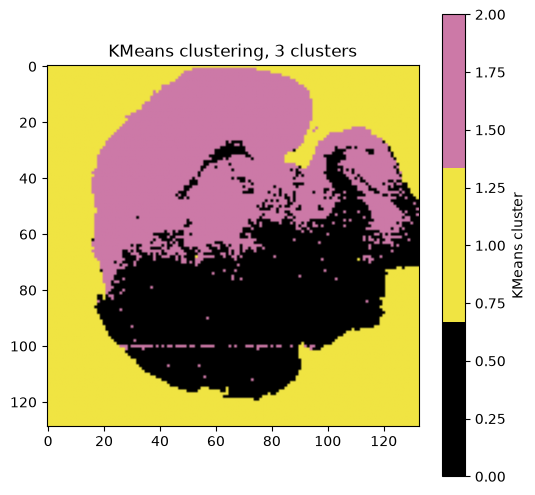

In [29]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init=20)
labels = kmeans.fit_predict(Data_n)

cluster_img = np.full((y.max(), x.max()), np.nan)
cluster_img[y - 1, x - 1] = labels

plt.figure(figsize=(6, 6))
cluster_cmap = plt.colormaps["okabe_ito"].resampled(3)
plt.imshow(cluster_img, cmap=cluster_cmap, origin="upper")
plt.axis("image")
plt.colorbar(label="KMeans cluster")
plt.title("KMeans clustering, 3 clusters")
plt.show()

## We can see that cluster 1 & 2 combined makes a potentially good tissue mask, let's try the effect of different normalisation though, here are the options:

## normalisation & scaling schemes:
## TIC
`data_norm(data, method='tic')`
## minmax
`data_norm(data, method='minmax')`
## mean-centering
`data_norm(data, method='snv')`
## PQN
`data_norm(data, method='pqn')`
## log transform offset by median
`data_norm(data, method='log')`

## you can do anyone, but log-transform has to **follow** any true normalisation (values between 0,1), as it will generate negative values which would not work with some of the normalisation schemes.

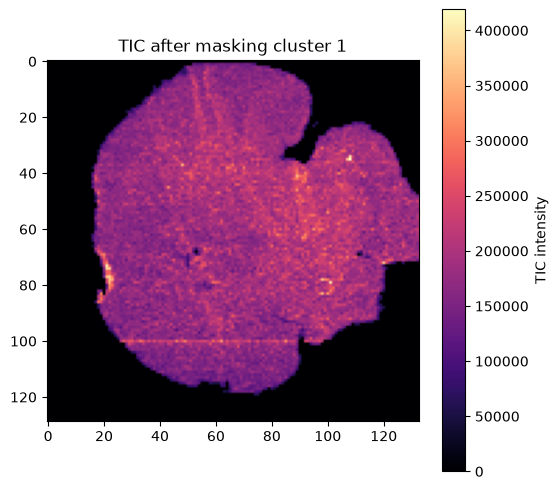

In [30]:
mask = (labels == 0)|(labels == 2)

data_m = data.to_numpy(float)
data_m[~mask, :] = 0
mz_m = mz

tic_m = data_m.sum(axis=1)

img_m = np.full((y.max(), x.max()), np.nan)
img_m[y - 1, x - 1] = tic_m

plt.figure(figsize=(6, 6))
plt.imshow(img_m, cmap="magma", origin="upper")
plt.axis("image")
plt.colorbar(label="TIC intensity")
plt.title("TIC after masking cluster 1")
plt.show()

## Let's look at the TIC spectrum again after filtering:

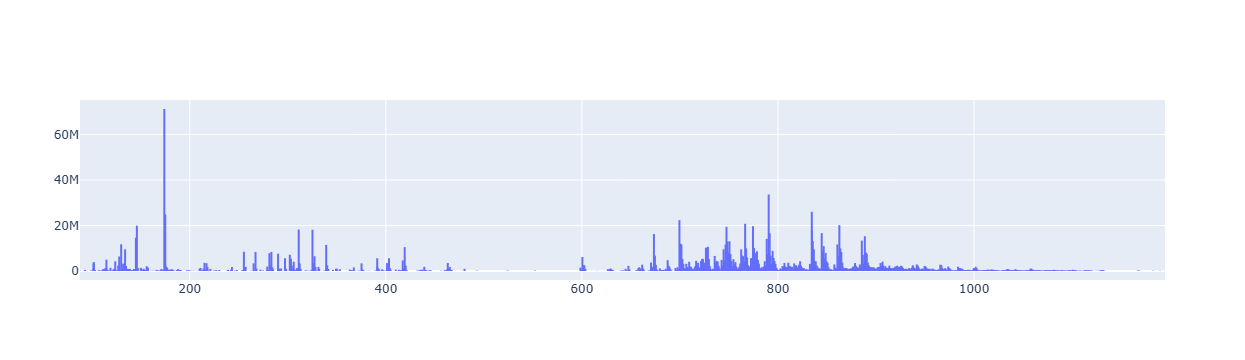

In [31]:
tic_spectrum_new = data_m.sum(axis=0)

fig = go.Figure(go.Scatter(
    x=np.repeat(mz, 3),
    y=np.ravel(np.column_stack([np.zeros_like(tic_spectrum), tic_spectrum_new, np.nan * tic_spectrum_new])),
    mode="lines"
))

fig.show()

## looks very similar, but note that the previously high background features e.g., m/z 325.18 are much lower now, and let's if they make it back into the top 10

C:\Users\yutinglu\AppData\Local\Temp\ipykernel_31840\272855542.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{current_title}\nTIC {tic_spectrum[i]:.3g}",


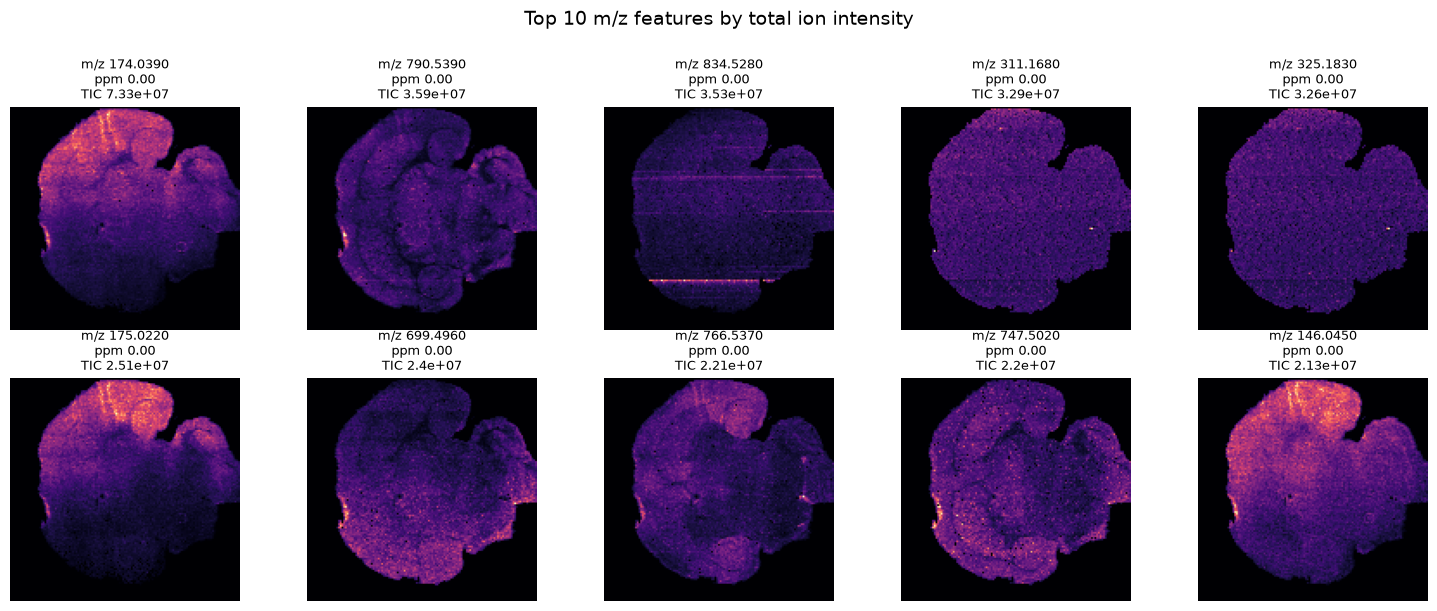

In [33]:
# Ten highest-TIC feature columns, ordered highest to lowest.
top10_idx = np.argsort(tic_spectrum)[-10:][::-1]

fig, ax = plt.subplots(2, 5, figsize=(15, 6))
ax = ax.ravel()

for a, i in zip(ax, top10_idx):
    plot_xic(
        data = data_m,
        target_mz=mz[i],
        max_x = x.max(), 
        max_y = y.max(),
        ax=a,
        add_colorbar=False
    )

    # Add the summed intensity under the m/z/ppm title.
    current_title = a.get_title()

    a.set_title(
        f"{current_title}\nTIC {tic_spectrum[i]:.3g}",
        fontsize=9
    )

fig.suptitle(
    "Top 10 m/z features by total ion intensity",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

## Still there, what about entropy:

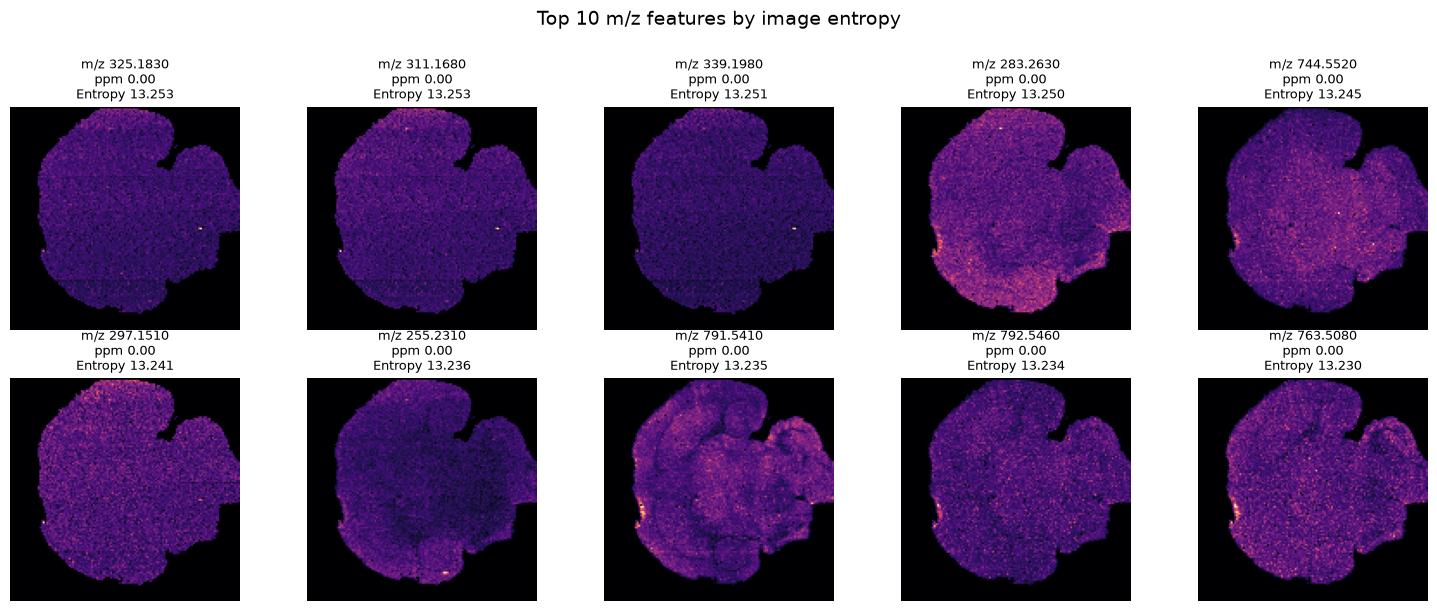

In [34]:
# Convert data once: works for either pandas DataFrame or NumPy array.
X = data_m

# Replace NaN/Inf and exclude negative values before calculating probabilities.
X = np.nan_to_num(
    X,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)
X = np.clip(X, 0, None)

# Normalize every m/z feature column independently:
# P[pixel, feature] = intensity / total intensity for that feature.
feature_sum = X.sum(axis=0)
safe_sum = np.where(feature_sum > 0, feature_sum, 1.0)
P = X / safe_sum

# Shannon entropy per feature image, with 0 * log2(0) treated as 0.
logP = np.zeros_like(P)
nonzero = P > 0
logP[nonzero] = np.log2(P[nonzero])

entropy_spectrum = -(P * logP).sum(axis=0)

# Empty ion images should not rank among the top features.
entropy_spectrum[feature_sum == 0] = 0.0

# Feature indices with the ten highest image entropies.
top10_idx = np.argsort(entropy_spectrum)[-10:][::-1]

fig, ax = plt.subplots(2, 5, figsize=(15, 6))
ax = ax.ravel()

for a, i in zip(ax, top10_idx):
    plot_xic(
        data = data_m,
        target_mz=mz[i],
        max_x = x.max(), 
        max_y = y.max(),
        ax=a,
        add_colorbar=False
    )

    # Preserve the m/z and ppm title generated by plot_xic.
    a.set_title(
        f"{a.get_title()}\nEntropy {entropy_spectrum[i]:.3f}",
        fontsize=9
    )

fig.suptitle(
    "Top 10 m/z features by image entropy",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

## so both metrics improve with background filtering!

## Let's now look at other common unsupervised methods to visualise the data, first we will switch to some bacterial data.

In [36]:
# data read in and formating
# change filepath
file = 'bacterial data_matrix_for_postprocessing.csv'
tmp_train, Data_train, mz = load_data(file,features = None)
condition = ((tmp_train['Class'] == 'PMIR') | (tmp_train['Class'] == 'PAER') | (tmp_train['Class'] == 'ECOL')
             | (tmp_train['Class'] == 'CTRO')| (tmp_train['Class'] == 'CPAR')| (tmp_train['Class'] == 'CALB'))
tmp_train = tmp_train.loc[condition,:]
Data_train = Data_train.loc[condition,:]
tmp_train

data already has the same spectral variables


,Sample,Class,134.0405,145.092,147.0398,149.0187,150.0359,151.0332,152.9887,155.077,...,983.7296,1015.5933,1058.6325,1082.6374,1083.6359,1084.6518,1085.6508,1086.6702,1087.6962,1112.6665
0,AZ008_0000571_20190227,PMIR,2450.706797,0.0,0.000000,0.0,1948.580373,0.000000,2181.548934,2594.073984,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1,AZ008_0000581_20190226,PMIR,2922.782717,0.0,0.000000,0.0,2149.931401,0.000000,1929.932893,2672.715285,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2,AZ008_0000599_20190225,PMIR,9001.065673,0.0,0.000000,0.0,3563.116391,0.000000,6070.902503,3439.338089,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
3,AZ008_0000606_20190226,PMIR,2518.612063,0.0,0.000000,0.0,2066.945701,0.000000,1529.152599,2333.057969,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
4,AZ008_0000611_20190227,PMIR,2476.696206,0.0,0.000000,0.0,2166.440815,0.000000,2509.743415,2316.661468,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,AZ008_0001557_20190303,CPAR,0.000000,0.0,1573.212654,0.0,0.000000,1861.815620,1838.936914,0.000000,...,0.0,0.000000,912.538344,968.052833,828.214586,1838.411720,1301.316214,895.950812,0.0,1041.263354
386,AZ008_0001562_20190303,CPAR,0.000000,0.0,1285.302467,0.0,0.000000,1651.218714,2980.419888,0.000000,...,0.0,1183.729441,1532.572090,1528.016934,1142.994654,2778.856001,1776.301661,1237.394003,0.0,1165.022701
387,AZ008_0001613_20190303,CPAR,0.000000,0.0,1309.075009,0.0,0.000000,1287.090080,977.285123,0.000000,...,0.0,0.000000,525.318880,549.399939,0.000000,861.529002,618.224030,526.446684,0.0,491.851171
388,AZ008_0002127_20190303,CPAR,0.000000,0.0,2664.426925,0.0,0.000000,3269.878052,4240.735064,0.000000,...,0.0,0.000000,1742.197086,1774.025561,0.000000,2975.999317,2012.571515,1544.634320,0.0,1541.263248


## There are 6 classes of bacteria contained in this data, let's try to visualise by PCA. First, without *any* normalisation/scaling.

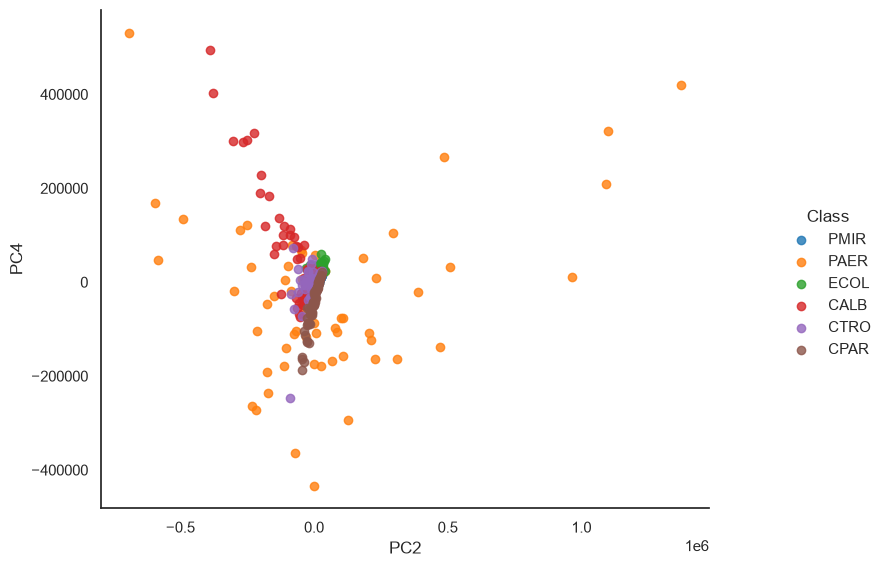

In [43]:
# PCA
sns.set_context("notebook")
sns.set_style("white")
from sklearn.decomposition import PCA
pca = PCA(n_components=5) #keep first 5 components
X_2D = pca.fit(Data_train).transform(Data_train)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2','PC3','PC4','PC5'])

# PCA_data=tmp_train_r.copy()
PCA_data=tmp_train.copy()
PCA_data['PC1'] = X_2D[:,0]
PCA_data['PC2'] = X_2D[:,1]
PCA_data['PC3'] = X_2D[:,2]
PCA_data['PC4'] = X_2D[:,3]
PCA_data['PC5'] = X_2D[:,4]


# sns.lmplot(x = "PC1", y = "PC2", hue='Cell line', data=PCA_data, palette=colors,fit_reg=False)
sns.lmplot(x = "PC2", y = "PC4", hue='Class', data=PCA_data, fit_reg=False)
fig = plt.gcf()
fig.set_size_inches(10,6)

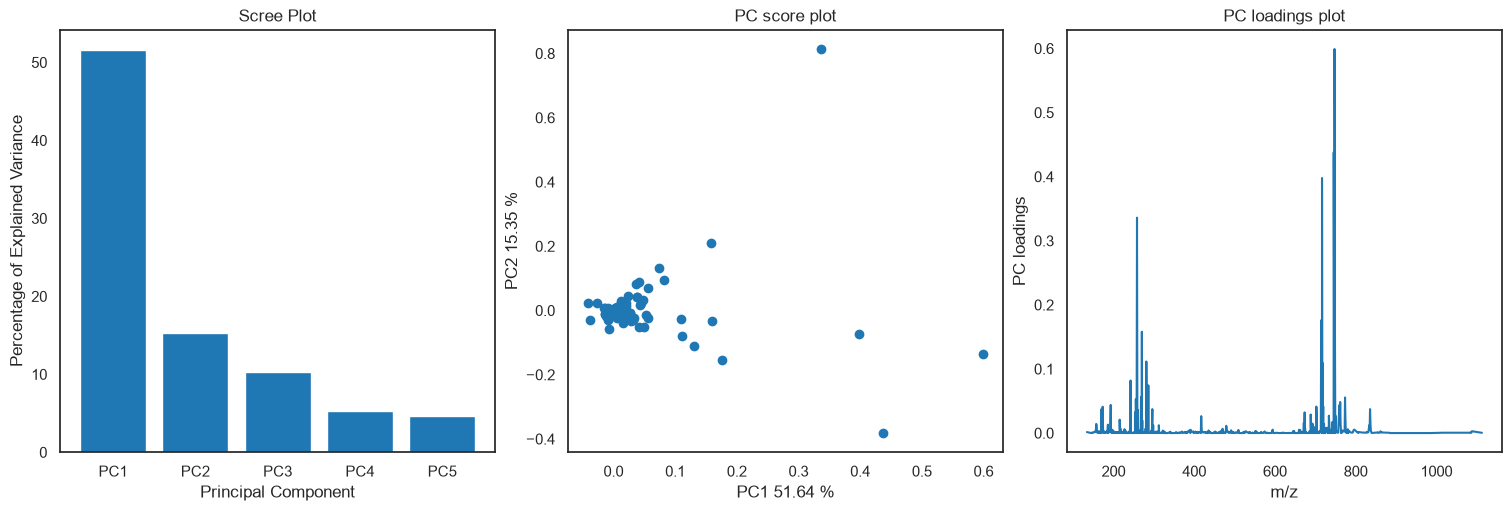

In [38]:
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

fig,axs = plt.subplots(ncols=3,constrained_layout=True,figsize=(15,5))

axs[0].bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
axs[0].set_ylabel('Percentage of Explained Variance')
axs[0].set_xlabel('Principal Component')
axs[0].set_title('Scree Plot')

axs[1].scatter(loadings['PC1'],loadings['PC2'])
axs[1].set_title('PC score plot')
axs[1].set_xlabel('PC1 %0.2f %%' % (pca.explained_variance_ratio_[0] * 100))
axs[1].set_ylabel('PC2 %0.2f %%' % (pca.explained_variance_ratio_[1] * 100))

axs[2].plot(mz,loadings['PC1'].abs())
axs[2].set_title('PC loadings plot')
axs[2].set_xlabel('m/z')
axs[2].set_ylabel('PC loadings');

## Without any normalisation, we do not see any bacteria-relevant separation in the data, at least not in the frist 2 components. Let's try 3:

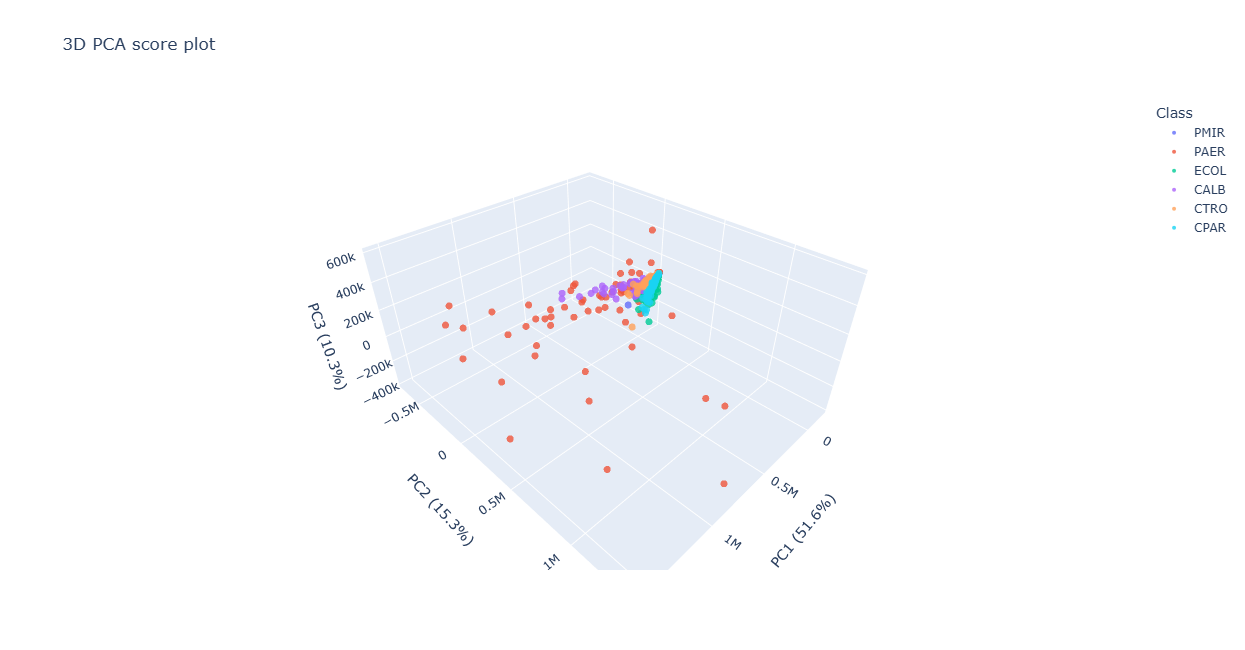

In [40]:
PCA_data = tmp_train.copy()

for i in range(5):
    PCA_data[f"PC{i+1}"] = X_2D[:, i]

fig = px.scatter_3d(
    PCA_data,
    x="PC1",
    y="PC2",
    z="PC5",
    color="Class",
    hover_data=["Class"],
    title="3D PCA score plot"
)

fig.update_traces(marker=dict(size=4, opacity=0.8))

fig.update_layout(
    width=800,
    height=650,
    scene=dict(
        xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
        yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
        zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"
    )
)

fig.show()

## So there is some separation in the first 3 components that we can potentially use to discover some biomarkers. The drawbacks of not normalising, however, should also become clear...
## the streaky patterns are essentially the intra-acquisition drift in the instrument and any systematic variation is amplified, e.g., in the PAER data points.
## Let's now normalise the data first before PCA, again with TIC+log:

In [44]:
Data_n = data_norm(Data_train, method='tic')
Data_log = data_norm(Data_n, method='log')

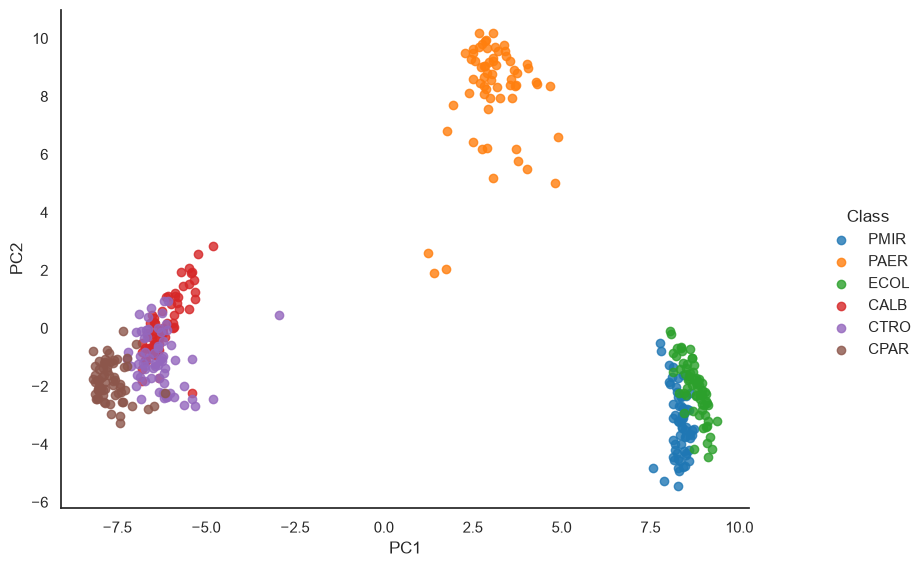

In [45]:
# PCA
sns.set_context("notebook")
sns.set_style("white")
from sklearn.decomposition import PCA
pca = PCA(n_components=5) #keep first 5 components
X_2D = pca.fit(Data_log).transform(Data_log)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2','PC3','PC4','PC5'])

# PCA_data=tmp_train_r.copy()
PCA_data=tmp_train.copy()
PCA_data['PC1'] = X_2D[:,0]
PCA_data['PC2'] = X_2D[:,1]
PCA_data['PC3'] = X_2D[:,2]
PCA_data['PC4'] = X_2D[:,3]
PCA_data['PC5'] = X_2D[:,4]


# sns.lmplot(x = "PC1", y = "PC2", hue='Cell line', data=PCA_data, palette=colors,fit_reg=False)
sns.lmplot(x = "PC1", y = "PC2", hue='Class', data=PCA_data, fit_reg=False)
fig = plt.gcf()
fig.set_size_inches(10,6)

## Much better! This is how PCA can also be used to QC your data, we are essentially looking for:
## 1. small intra-class distance (tight clustering between same class)
## 2. large inter-class distance (clear separation between different classes)

## Again, feel free to play with the normalisation strategy

## Finally, let's try UMAP:

C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


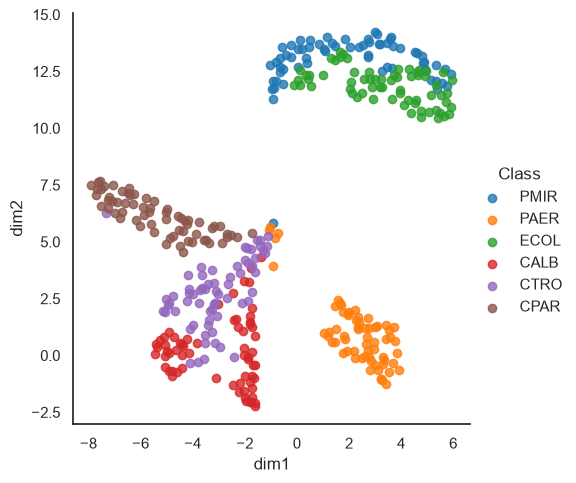

In [46]:
embedding = umap.UMAP(
    init="pca",
    n_neighbors=15,
    min_dist=0.5,
    n_components=2,
    random_state=0
).fit_transform(Data_train)

UMAP_data = tmp_train.copy()
UMAP_data['dim1'] = embedding[:,0]
UMAP_data['dim2'] = embedding[:,1]

sns.lmplot(x = "dim1", y = "dim2", hue='Class', data=UMAP_data, fit_reg=False)

## So even without normalisation, UMAP seems to be able to separate the biological differences fairly well. How?
## Remeber how UMAP works, some of the limitations in raw data e.g., systematic drift, follows a non-linear pattern, which may somewhat remedied by the way UMAP is intrinsically optimised.
## either way, let's try the normalised version:

C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


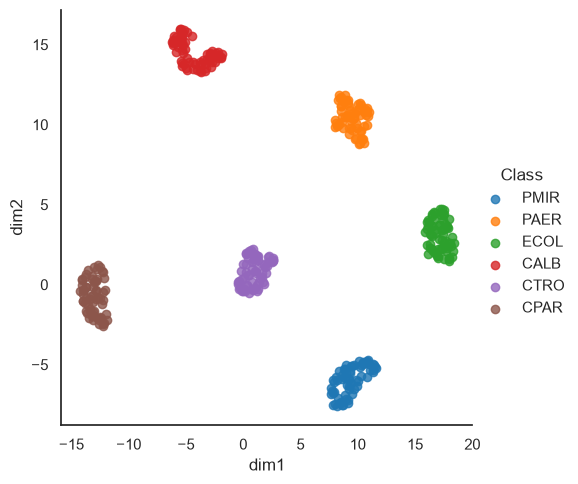

In [47]:
embedding = umap.UMAP(
    init="pca",
    n_neighbors=15,
    min_dist=0.5,
    n_components=2,
    random_state=0
).fit_transform(Data_log)

UMAP_data = tmp_train.copy()
UMAP_data['dim1'] = embedding[:,0]
UMAP_data['dim2'] = embedding[:,1]

sns.lmplot(x = "dim1", y = "dim2", hue='Class', data=UMAP_data, fit_reg=False)

## Lastly, to emphasise on the caution on hyperparameter optimisation, let's see what happens if I 'unoptimise' parameters:

C:\Users\yutinglu\anaconda3\envs\TUMD4\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


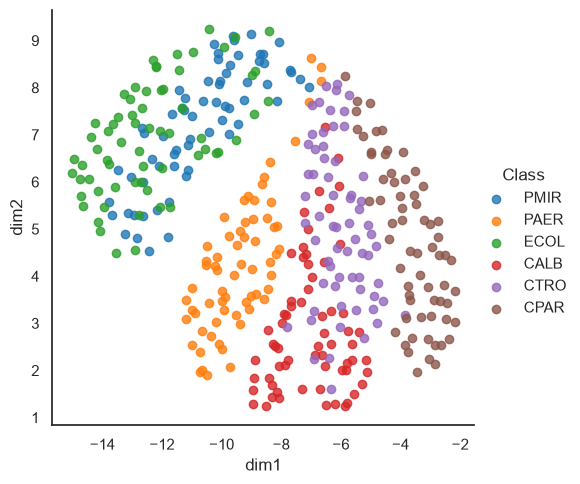

In [48]:
embedding = umap.UMAP(
    init="spectral",
    n_neighbors=200,
    min_dist=0.9,
    n_components=2,
    random_state=0
).fit_transform(Data_train)

UMAP_data = tmp_train.copy()
UMAP_data['dim1'] = embedding[:,0]
UMAP_data['dim2'] = embedding[:,1]

sns.lmplot(x = "dim1", y = "dim2", hue='Class', data=UMAP_data, fit_reg=False)